# Whale Signal Backtest — 5-Minute Scalping Strategy

**Hypothesis**: Whale market makers in 4h BTC Up/Down markets pull/reposition their orders 2-3 seconds before large BTC moves. We can use these signals to place directional bets in concurrent 5-minute markets.

**Signal types observed live (March 10, 2026)**:
1. **Ask pull**: Whale ask disappears entirely (was 1000+ tokens)
2. **Bid retreat**: Whale bid drops significantly (≥3 ticks)
3. **Bid pull**: Whale bid disappears entirely
4. **Ask tighten**: Whale ask moves toward mid (rushing to dump)
5. **Full vanish**: All whale orders disappear simultaneously

**Data**:
- 4h orderbook snapshots: `data/telonex_btc_4h_book_snapshots/` (798 files, 5 levels, has `token_label`)
- 5m orderbook snapshots: `data/telonex_book_snapshots/` (7,187 files, 5 levels, has `token_label`)
- Overlap period: Feb 12 – Mar 6, 2026 (~22 days, 139 4h markets)

In [20]:
import os
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("../data")
DIR_4H = DATA_DIR / "telonex_btc_4h_book_snapshots"
DIR_5M_BOOK = DATA_DIR / "telonex_book_snapshots"  # normalized with token_label

# Overlap period (telonex 5m starts Feb 12)
OVERLAP_START = 1770854400  # Feb 12, 2026 00:00 UTC                                                                                
OVERLAP_END   = 1772834400  # Mar 6, 2026 22:00 UTC  

print(f"4h files: {len(list(DIR_4H.glob('*.parquet')))}")
print(f"5m book files (telonex): {len(list(DIR_5M_BOOK.glob('*.parquet')))}")

4h files: 798
5m book files (telonex): 7187


## Step 1: Load 4h orderbook data and extract whale presence

For each 4h market in the overlap period, load all snapshots and track the largest resting orders across all 5 levels. A "whale" is any order ≥ `WHALE_THRESHOLD` tokens.

In [21]:
WHALE_THRESHOLD = 2500  # only the dominant MMs (~2500 and ~4800 token orders)
TICK = 0.01

def extract_whale_features(df_token: pd.DataFrame) -> pd.DataFrame:
    """Vectorized whale feature extraction for one token (Up or Down).
    
    Scans all 5 book levels for orders >= WHALE_THRESHOLD and extracts
    best whale bid/ask price, size, and totals — all without Python loops.
    """
    out = pd.DataFrame({"ts_ms": df_token["exchange_timestamp"].values})
    out["mid_price"] = df_token["mid_price"].values
    out["best_bid"] = df_token["bid_price_1"].values
    out["best_ask"] = df_token["ask_price_1"].values

    for side, price_sign in [("bid", 1), ("ask", 1)]:
        # Stack all 5 levels: shape (n_rows, 5)
        sizes = np.column_stack([df_token[f"{side}_size_{i}"].values for i in range(1, 6)])
        prices = np.column_stack([df_token[f"{side}_price_{i}"].values for i in range(1, 6)])

        whale_mask = (sizes >= WHALE_THRESHOLD) & (prices > 0)
        
        # Total whale size per row
        whale_sizes = np.where(whale_mask, sizes, 0)
        out[f"total_whale_{side}"] = whale_sizes.sum(axis=1)

        # Best whale price/size: first level (col) that qualifies per row
        # For bids: level 1 is best (highest); for asks: level 1 is best (lowest)
        # argmax on mask gives first True per row; if no True, returns 0 (so check any)
        has_whale = whale_mask.any(axis=1)
        first_whale_idx = whale_mask.argmax(axis=1)  # index of first qualifying level
        
        row_idx = np.arange(len(df_token))
        best_price = prices[row_idx, first_whale_idx]
        best_size = sizes[row_idx, first_whale_idx]
        
        out[f"whale_{side}_price"] = np.where(has_whale, best_price, np.nan)
        out[f"whale_{side}_size"] = np.where(has_whale, best_size, 0)

    return out


def load_4h_files_in_overlap():
    """Load all 4h parquet files whose market start time falls in the overlap period."""
    files = sorted(DIR_4H.glob("*.parquet"))
    overlap = []
    for f in files:
        epoch = int(f.stem.split("-")[-1])
        if OVERLAP_START <= epoch <= OVERLAP_END:
            overlap.append((epoch, f))
    return overlap

overlap_4h = load_4h_files_in_overlap()
print(f"4h markets in overlap period: {len(overlap_4h)}")
print(f"First: {datetime.fromtimestamp(overlap_4h[0][0], tz=timezone.utc)}")
print(f"Last:  {datetime.fromtimestamp(overlap_4h[-1][0], tz=timezone.utc)}")

4h markets in overlap period: 138
First: 2026-02-12 01:00:00+00:00
Last:  2026-03-06 21:00:00+00:00


In [22]:
# Test extract_whale_features on one file
test_epoch, test_file = overlap_4h[50]
test_df = pq.read_table(str(test_file)).to_pandas()
test_up = test_df[test_df.token_label == "Up"].sort_values("exchange_timestamp").reset_index(drop=True)

whale_up = extract_whale_features(test_up)
has_whale = whale_up[whale_up.whale_ask_price.notna()]
print(f"Test market: {datetime.fromtimestamp(test_epoch, tz=timezone.utc)}")
print(f"Total snapshots: {len(whale_up)}, with whale ask: {len(has_whale)} ({len(has_whale)/len(whale_up)*100:.1f}%)")
print(f"Whale ask sizes: min={has_whale.whale_ask_size.min():.0f}, max={has_whale.whale_ask_size.max():.0f}, median={has_whale.whale_ask_size.median():.0f}")
whale_up.head(10)

Test market: 2026-02-20 09:00:00+00:00
Total snapshots: 19856, with whale ask: 13259 (66.8%)
Whale ask sizes: min=2500, max=52015, median=2500


,ts_ms,mid_price,best_bid,best_ask,total_whale_bid,whale_bid_price,whale_bid_size,total_whale_ask,whale_ask_price,whale_ask_size
0,1771578005010,0.475,0.46,0.49,0.0,NaN,0.0,0.0,NaN,0.0
1,1771578005013,0.475,0.46,0.49,0.0,NaN,0.0,0.0,NaN,0.0
2,1771578005039,0.475,0.46,0.49,0.0,NaN,0.0,0.0,NaN,0.0
3,1771578005352,0.475,0.46,0.49,0.0,NaN,0.0,0.0,NaN,0.0
4,1771578005355,0.480,0.47,0.49,0.0,NaN,0.0,0.0,NaN,0.0
5,1771578005360,0.480,0.47,0.49,0.0,NaN,0.0,0.0,NaN,0.0
6,1771578008487,0.485,0.47,0.50,0.0,NaN,0.0,0.0,NaN,0.0
7,1771578008504,0.490,0.48,0.50,0.0,NaN,0.0,0.0,NaN,0.0
8,1771578009855,0.490,0.48,0.50,0.0,NaN,0.0,0.0,NaN,0.0
9,1771578010352,0.490,0.48,0.50,0.0,NaN,0.0,0.0,NaN,0.0


## Step 2: Detect whale signals

Compare consecutive snapshots to detect:
1. **Ask pull**: whale ask was present, now gone
2. **Bid pull**: whale bid was present, now gone
3. **Bid retreat**: whale bid dropped ≥ N ticks
4. **Ask tighten**: whale ask moved toward mid ≥ N ticks (rushing to sell)
5. **Full vanish**: both bid and ask whale orders disappear simultaneously

Each signal gets a direction prediction:
- Ask pull on Up → **bearish** (whale pulling their Up sell = they think Up will resolve YES, i.e. BTC going up... wait, no: pulling ask = they don't want to sell at that price anymore = they think the token is worth MORE = BTC going up for Up token)
- Actually, let's think about this more carefully in the signal detection code.

In [23]:
WHALE_MOVE_TICKS = 3  # minimum tick movement to count as retreat/tighten
MIN_ABSENT_SNAPSHOTS = 3  # whale must be gone for N consecutive snapshots to count as a pull

def _count_consecutive_absent(present: np.ndarray) -> np.ndarray:
    """For each position where present goes from True→False, count how many
    consecutive False snapshots follow (including the current one).
    
    Returns an array the same length as `present` with the run length at each
    transition point, 0 elsewhere.
    """
    n = len(present)
    absent = ~present
    
    # Build cumulative run lengths of consecutive absences (reset on present=True)
    # Work backwards: run_len[i] = how many consecutive absences from i onward
    run_len = np.zeros(n, dtype=np.int32)
    if absent[-1]:
        run_len[-1] = 1
    for i in range(n - 2, -1, -1):
        if absent[i]:
            run_len[i] = run_len[i + 1] + 1
        # else stays 0
    
    return run_len


def detect_whale_signals(whale_df: pd.DataFrame, token_label: str) -> pd.DataFrame:
    """Vectorized whale signal detection with snapshot-count persistence filter.
    
    Pull signals only fire when the whale stays absent for MIN_ABSENT_SNAPSHOTS
    consecutive snapshots after disappearing. The signal timestamp is still the
    moment of disappearance (not the confirmation point), so it's actionable
    in real-time once you've tuned the threshold to filter flickers.
    """
    move_threshold = WHALE_MOVE_TICKS * TICK
    n = len(whale_df)
    
    ts = whale_df["ts_ms"].values
    ask_price = whale_df["whale_ask_price"].values
    ask_size = whale_df["whale_ask_size"].values
    bid_price = whale_df["whale_bid_price"].values
    bid_size = whale_df["whale_bid_size"].values
    
    ask_present = np.isfinite(ask_price)
    bid_present = np.isfinite(bid_price)
    
    # Consecutive-absence run lengths for persistence filtering
    ask_absent_run = _count_consecutive_absent(ask_present)
    bid_absent_run = _count_consecutive_absent(bid_present)
    
    # Previous snapshot values
    prev_ask_price = np.roll(ask_price, 1)
    prev_ask_size = np.roll(ask_size, 1)
    prev_bid_price = np.roll(bid_price, 1)
    prev_bid_size = np.roll(bid_size, 1)
    prev_ask_present = np.roll(ask_present, 1)
    prev_bid_present = np.roll(bid_present, 1)
    prev_ask_present[0] = False
    prev_bid_present[0] = False
    
    signals = []
    
    # --- Ask pull: was present, now gone, stays gone for N snapshots ---
    ask_pull = prev_ask_present & ~ask_present & (ask_absent_run >= MIN_ABSENT_SNAPSHOTS)
    if ask_pull.any():
        idx = np.where(ask_pull)[0]
        direction = "up" if token_label == "Up" else "down"
        signals.append(pd.DataFrame({
            "ts_ms": ts[idx],
            "signal_type": "ask_pull",
            "token": token_label,
            "direction": direction,
            "strength": prev_ask_size[idx],
            "detail": [f"{token_label} ask {prev_ask_price[i]:.2f} ({prev_ask_size[i]:.0f}) GONE ({ask_absent_run[i]} snaps)" for i in idx],
        }))
    
    # --- Ask tighten: moved closer to mid ---
    ask_tighten = prev_ask_present & ask_present & ((prev_ask_price - ask_price) >= move_threshold)
    if ask_tighten.any():
        idx = np.where(ask_tighten)[0]
        direction = "down" if token_label == "Up" else "up"
        ticks = (prev_ask_price[idx] - ask_price[idx]) / TICK
        signals.append(pd.DataFrame({
            "ts_ms": ts[idx],
            "signal_type": "ask_tighten",
            "token": token_label,
            "direction": direction,
            "strength": ticks,
            "detail": [f"{token_label} ask dropped {t:.0f} ticks ({prev_ask_price[i]:.2f}→{ask_price[i]:.2f})" for i, t in zip(idx, ticks)],
        }))
    
    # --- Bid pull: was present, now gone, stays gone for N snapshots ---
    bid_pull = prev_bid_present & ~bid_present & (bid_absent_run >= MIN_ABSENT_SNAPSHOTS)
    if bid_pull.any():
        idx = np.where(bid_pull)[0]
        direction = "down" if token_label == "Up" else "up"
        signals.append(pd.DataFrame({
            "ts_ms": ts[idx],
            "signal_type": "bid_pull",
            "token": token_label,
            "direction": direction,
            "strength": prev_bid_size[idx],
            "detail": [f"{token_label} bid {prev_bid_price[i]:.2f} ({prev_bid_size[i]:.0f}) GONE ({bid_absent_run[i]} snaps)" for i in idx],
        }))
    
    # --- Bid retreat: moved away from mid ---
    bid_retreat = prev_bid_present & bid_present & ((prev_bid_price - bid_price) >= move_threshold)
    if bid_retreat.any():
        idx = np.where(bid_retreat)[0]
        direction = "down" if token_label == "Up" else "up"
        ticks = (prev_bid_price[idx] - bid_price[idx]) / TICK
        signals.append(pd.DataFrame({
            "ts_ms": ts[idx],
            "signal_type": "bid_retreat",
            "token": token_label,
            "direction": direction,
            "strength": ticks,
            "detail": [f"{token_label} bid dropped {t:.0f} ticks ({prev_bid_price[i]:.2f}→{bid_price[i]:.2f})" for i, t in zip(idx, ticks)],
        }))
    
    if signals:
        return pd.concat(signals, ignore_index=True)
    return pd.DataFrame(columns=["ts_ms", "signal_type", "token", "direction", "strength", "detail"])


# Test on one file at different snapshot thresholds
test_epoch, test_file = overlap_4h[50]
test_df_full = pq.read_table(str(test_file)).to_pandas()

for n_snaps in [1, 2, 3, 5, 10]:
    MIN_ABSENT_SNAPSHOTS = n_snaps
    parts = []
    for label in ["Up", "Down"]:
        token_df = test_df_full[test_df_full.token_label == label].sort_values("exchange_timestamp").reset_index(drop=True)
        whale_feats = extract_whale_features(token_df)
        parts.append(detect_whale_signals(whale_feats, label))
    sigs = pd.concat(parts, ignore_index=True)
    pulls = sigs[sigs.signal_type.isin(["ask_pull", "bid_pull"])]
    other = sigs[~sigs.signal_type.isin(["ask_pull", "bid_pull"])]
    print(f"  min_absent={n_snaps:2d} → {len(pulls):4d} pulls, {len(other):4d} retreat/tighten, {len(sigs):4d} total")

MIN_ABSENT_SNAPSHOTS = 3  # restore default

  min_absent= 1 → 1702 pulls,   38 retreat/tighten, 1740 total
  min_absent= 2 → 1096 pulls,   38 retreat/tighten, 1134 total
  min_absent= 3 →  868 pulls,   38 retreat/tighten,  906 total
  min_absent= 5 →  600 pulls,   38 retreat/tighten,  638 total
  min_absent=10 →  300 pulls,   38 retreat/tighten,  338 total


## Step 3: Process all 4h markets and collect signals

Scan every 4h market in the overlap period. Also add **corroborating signal detection**: when Up and Down signals fire within a short window pointing the same direction, that's a stronger signal (like the "full vanish" we observed live).

In [24]:
def process_all_4h_signals(overlap_files: list[tuple[int, Path]]) -> pd.DataFrame:
    """Process all 4h markets and return a DataFrame of all whale signals."""
    all_parts = []
    markets_with_whales = 0
    
    for epoch, fpath in overlap_files:
        df = pq.read_table(str(fpath)).to_pandas()
        parts = []
        
        for label in ["Up", "Down"]:
            token_df = df[df.token_label == label].sort_values("exchange_timestamp").reset_index(drop=True)
            if len(token_df) == 0:
                continue
            whale_feats = extract_whale_features(token_df)
            sigs = detect_whale_signals(whale_feats, label)
            if len(sigs) > 0:
                parts.append(sigs)
        
        if parts:
            market_sigs = pd.concat(parts, ignore_index=True)
            market_sigs["market_epoch"] = epoch
            market_sigs["market_end"] = epoch + 4 * 3600
            markets_with_whales += 1
            all_parts.append(market_sigs)
    
    print(f"Processed {len(overlap_files)} markets, {markets_with_whales} had whale signals")
    if all_parts:
        return pd.concat(all_parts, ignore_index=True)
    return pd.DataFrame()

all_signals = process_all_4h_signals(overlap_4h)
print(f"\nTotal signals: {len(all_signals)}")
print(f"\nBy type:\n{all_signals.signal_type.value_counts()}")
print(f"\nBy direction:\n{all_signals.direction.value_counts()}")
print(f"\nBy token:\n{all_signals.token.value_counts()}")

Processed 138 markets, 137 had whale signals

Total signals: 247730

By type:
signal_type
bid_pull       81074
ask_pull       81074
bid_retreat    43252
ask_tighten    42330
Name: count, dtype: int64

By direction:
direction
down    125875
up      121855
Name: count, dtype: int64

By token:
token
Up      123945
Down    123785
Name: count, dtype: int64


In [25]:
CORROBORATION_WINDOW_MS = 5000  # signals within 5s pointing same direction = corroborated

def add_corroboration(signals_df: pd.DataFrame) -> pd.DataFrame:
    """Mark signals corroborated by the opposite token within the window.
    
    Uses a merge_asof approach instead of O(n^2) row-by-row comparison.
    """
    df = signals_df.sort_values("ts_ms").reset_index(drop=True)
    df["corroborated"] = False
    
    if len(df) == 0:
        return df
    
    # For each (market, direction), check if both tokens have signals within window
    for (market, direction), grp in df.groupby(["market_epoch", "direction"]):
        up_idx = grp.index[grp.token == "Up"]
        down_idx = grp.index[grp.token == "Down"]
        
        if len(up_idx) == 0 or len(down_idx) == 0:
            continue
        
        up_ts = df.loc[up_idx, "ts_ms"].values
        down_ts = df.loc[down_idx, "ts_ms"].values
        
        # For each Up signal, find nearest Down signal
        for ui, uts in zip(up_idx, up_ts):
            if np.any(np.abs(down_ts - uts) <= CORROBORATION_WINDOW_MS):
                df.loc[ui, "corroborated"] = True
        
        # For each Down signal, find nearest Up signal
        for di, dts in zip(down_idx, down_ts):
            if np.any(np.abs(up_ts - dts) <= CORROBORATION_WINDOW_MS):
                df.loc[di, "corroborated"] = True
    
    return df

all_signals = add_corroboration(all_signals)
corr = all_signals[all_signals.corroborated]
print(f"Corroborated signals: {len(corr)} / {len(all_signals)} ({len(corr)/len(all_signals)*100:.1f}%)" if len(all_signals) > 0 else "No signals")
if len(corr) > 0:
    print(f"\nCorroborated by type:\n{corr.signal_type.value_counts()}")
    print(f"\nSample corroborated signals:")
    for _, row in corr.head(5).iterrows():
        print(f"  {row.detail}")

Corroborated signals: 180747 / 247730 (73.0%)

Corroborated by type:
signal_type
ask_pull       81074
bid_pull       81074
ask_tighten    10141
bid_retreat     8458
Name: count, dtype: int64

Sample corroborated signals:
  Down ask 0.99 (4048) GONE (3 snaps)
  Up bid 0.01 (4048) GONE (3 snaps)
  Up bid 0.01 (4048) GONE (10 snaps)
  Down ask 0.99 (4048) GONE (10 snaps)
  Up bid 0.01 (4048) GONE (3 snaps)


## Step 4: Map signals to concurrent 5-minute markets

For each whale signal, find the 5-minute market that was active at signal time. Then simulate buying the predicted winning token at the best ask and holding to resolution.

In [26]:
def build_5m_index() -> pd.DataFrame:
    """Build an index of all 5m telonex book snapshot files with their epoch times."""
    files = sorted(DIR_5M_BOOK.glob("*.parquet"))
    rows = []
    for f in files:
        epoch = int(f.stem.split("-")[-1])
        rows.append({"epoch": epoch, "book_file": f})
    return pd.DataFrame(rows)

index_5m = build_5m_index()
print(f"5m files indexed: {len(index_5m)}")

def find_5m_market_at(signal_ts_ms: int, market_4h_epoch: int) -> list[dict]:
    """Find 5m markets active at the signal timestamp.
    
    Returns list of dicts with: epoch, book_file
    5m markets start every 300s, last ~300s, within the 4h window.
    """
    signal_ts_s = signal_ts_ms / 1000
    
    # Find 5m file whose epoch is <= signal_ts and epoch + 300 > signal_ts
    candidates = index_5m[
        (index_5m.epoch <= signal_ts_s) & 
        (index_5m.epoch + 300 > signal_ts_s) &
        (index_5m.epoch >= market_4h_epoch) &
        (index_5m.epoch < market_4h_epoch + 14400)
    ]
    
    if len(candidates) == 0:
        # Try a wider window — signal might be near market boundary
        candidates = index_5m[
            (abs(index_5m.epoch - signal_ts_s) < 300) &
            (index_5m.epoch >= market_4h_epoch) &
            (index_5m.epoch < market_4h_epoch + 14400)
        ]
    
    return candidates.to_dict("records")

# Test
test_sig = all_signals.iloc[0]
matches = find_5m_market_at(test_sig.ts_ms, test_sig.market_epoch)
print(f"\nTest signal at {test_sig.ts_ms} (4h market {test_sig.market_epoch}):")
print(f"  Found {len(matches)} 5m market(s)")

5m files indexed: 7187

Test signal at 1770870258734 (4h market 1770858000):
  Found 1 5m market(s)


In [27]:
def determine_5m_outcome(book_file: Path, signal_ts_ms: int) -> dict | None:
    """Determine the outcome of a 5m market and entry conditions at signal time.
    
    Uses token_label column from telonex data to definitively identify Up/Down tokens.
    
    Returns dict with: market_id, winner ('up'/'down'/None),
                       up_entry_ask, down_entry_ask, up_final_mid, down_final_mid
    """
    try:
        book_df = pq.read_table(str(book_file)).to_pandas()
    except Exception:
        return None
    
    if len(book_df) == 0 or "token_label" not in book_df.columns:
        return None
    
    # Use token_label to split Up/Down — no heuristic needed
    up_df = book_df[book_df.token_label == "Up"].sort_values("exchange_timestamp")
    down_df = book_df[book_df.token_label == "Down"].sort_values("exchange_timestamp")
    
    if len(up_df) < 3 or len(down_df) < 3:
        return None
    
    # Determine outcome from final mid_prices
    up_final = up_df.iloc[-1].mid_price
    down_final = down_df.iloc[-1].mid_price
    
    # Need clear resolution: one token near 1.0, other near 0.0
    if abs(up_final - down_final) < 0.30:
        return None  # Market not clearly resolved in our data window
    
    winner = "up" if up_final > down_final else "down"
    
    # Entry prices: best ask at or just after signal time
    def get_entry_ask(token_df, ts_ms):
        after = token_df[token_df.exchange_timestamp >= ts_ms]
        if len(after) > 0:
            ask = after.iloc[0].ask_price_1
            return ask if ask > 0 else None
        # If signal is after last snapshot, use last available
        ask = token_df.iloc[-1].ask_price_1
        return ask if ask > 0 else None
    
    up_entry = get_entry_ask(up_df, signal_ts_ms)
    down_entry = get_entry_ask(down_df, signal_ts_ms)
    
    if up_entry is None or down_entry is None:
        return None
    
    return {
        "market_id": up_df.iloc[0].get("market", "unknown"),
        "winner": winner,
        "up_entry_ask": up_entry,
        "down_entry_ask": down_entry,
        "up_final_mid": up_final,
        "down_final_mid": down_final,
        "n_snapshots": len(book_df),
    }

# Test
if matches:
    m = matches[0]
    outcome = determine_5m_outcome(m["book_file"], test_sig.ts_ms)
    if outcome:
        print(f"5m outcome: winner={outcome['winner']}, up_entry={outcome['up_entry_ask']:.2f}, down_entry={outcome['down_entry_ask']:.2f}")
        print(f"  up_final={outcome['up_final_mid']:.2f}, down_final={outcome['down_final_mid']:.2f}")
    else:
        print("Could not determine outcome for test market")

5m outcome: winner=down, up_entry=0.06, down_entry=0.98
  up_final=0.01, down_final=0.49


## Step 5: Run the backtest

For each whale signal:
1. Find the active 5m market
2. Determine entry price (best ask of predicted winning token)
3. Simulate holding to resolution
4. PnL = `$BET_SIZE * (1.0 - entry_price)` if correct, `$BET_SIZE * (-entry_price)` if wrong

Deduplicate signals: if multiple signals fire within a cooldown window for the same direction, only trade once.

In [28]:
BET_SIZE = 20.0  # dollars per trade
COOLDOWN_MS = 30_000  # don't re-enter same direction within 30s
MAX_ENTRY_PRICE = 0.85  # cap entry price (payoff asymmetry above this)

def run_backtest(
    signals_df: pd.DataFrame,
    bet_size: float = BET_SIZE,
    cooldown_ms: int = COOLDOWN_MS,
    max_entry: float = MAX_ENTRY_PRICE,
    require_corroboration: bool = False,
    signal_types: list[str] | None = None,
) -> pd.DataFrame:
    """Run the backtest across all signals.
    
    Returns DataFrame of trades with PnL.
    """
    df = signals_df.sort_values("ts_ms").reset_index(drop=True)
    
    if require_corroboration:
        df = df[df.corroborated].reset_index(drop=True)
    
    if signal_types:
        df = df[df.signal_type.isin(signal_types)].reset_index(drop=True)
    
    trades = []
    last_trade_ts = {}  # direction -> last trade timestamp
    
    # Cache 5m outcomes to avoid re-reading files
    outcome_cache = {}
    
    for _, sig in df.iterrows():
        direction = sig.direction
        ts = sig.ts_ms
        
        # Cooldown check
        if direction in last_trade_ts and ts - last_trade_ts[direction] < cooldown_ms:
            continue
        
        # Find 5m market
        matches = find_5m_market_at(ts, sig.market_epoch)
        if not matches:
            continue
        
        m = matches[0]
        cache_key = (m["epoch"], str(m["book_file"]))
        
        if cache_key not in outcome_cache:
            outcome_cache[cache_key] = determine_5m_outcome(m["book_file"], ts)
        
        outcome = outcome_cache[cache_key]
        if outcome is None:
            continue
        
        # Entry price for predicted winning token
        if direction == "up":
            entry_price = outcome["up_entry_ask"]
        else:
            entry_price = outcome["down_entry_ask"]
        
        # Skip if entry too expensive or invalid
        if entry_price <= 0 or entry_price > max_entry:
            continue
        
        # Determine if our prediction was correct
        correct = (outcome["winner"] == direction)
        
        # PnL calculation
        tokens = bet_size / entry_price
        if correct:
            pnl = tokens * (1.0 - entry_price)  # win: pay entry, receive 1.0
        else:
            pnl = -bet_size  # lose: lose entire bet
        
        last_trade_ts[direction] = ts
        
        trades.append({
            "ts_ms": ts,
            "signal_type": sig.signal_type,
            "token": sig.token,
            "direction": direction,
            "corroborated": sig.corroborated,
            "entry_price": entry_price,
            "correct": correct,
            "pnl": pnl,
            "bet_size": bet_size,
            "market_5m_epoch": m["epoch"],
            "market_4h_epoch": sig.market_epoch,
            "detail": sig.detail,
        })
    
    return pd.DataFrame(trades)

# Run base backtest
trades = run_backtest(all_signals)
print(f"Total trades: {len(trades)}")
if len(trades) > 0:
    print(f"Win rate: {trades.correct.mean()*100:.1f}%")
    print(f"Total PnL: ${trades.pnl.sum():.2f}")
    print(f"Avg PnL/trade: ${trades.pnl.mean():.2f}")
    print(f"Avg entry price: {trades.entry_price.mean():.3f}")
    print(f"\nBy signal type:")
    for st, grp in trades.groupby("signal_type"):
        print(f"  {st}: {len(grp)} trades, WR={grp.correct.mean()*100:.1f}%, PnL=${grp.pnl.sum():.2f}")
    print(f"\nBy direction:")
    for d, grp in trades.groupby("direction"):
        print(f"  {d}: {len(grp)} trades, WR={grp.correct.mean()*100:.1f}%, PnL=${grp.pnl.sum():.2f}")

Total trades: 37307
Win rate: 49.2%
Total PnL: $-19441.95
Avg PnL/trade: $-0.52
Avg entry price: 0.500

By signal type:
  ask_pull: 13209 trades, WR=48.9%, PnL=$-7278.59
  ask_tighten: 5178 trades, WR=52.5%, PnL=$3481.16
  bid_pull: 13029 trades, WR=49.1%, PnL=$-7957.24
  bid_retreat: 5891 trades, WR=47.5%, PnL=$-7687.28

By direction:
  down: 18778 trades, WR=48.0%, PnL=$-13577.00
  up: 18529 trades, WR=50.4%, PnL=$-5864.95


## Step 6: Corroborated-only backtest

Test hypothesis: signals corroborated by the opposite token (e.g., Up ask pull + Down bid pull within 5s) should be stronger.

In [29]:
# Corroborated signals only
trades_corr = run_backtest(all_signals, require_corroboration=True)
print("=== Corroborated signals only ===")
if len(trades_corr) > 0:
    print(f"Trades: {len(trades_corr)}, WR: {trades_corr.correct.mean()*100:.1f}%")
    print(f"PnL: ${trades_corr.pnl.sum():.2f}, Avg: ${trades_corr.pnl.mean():.2f}")
    print(f"\nBy signal type:")
    for st, grp in trades_corr.groupby("signal_type"):
        print(f"  {st}: {len(grp)} trades, WR={grp.correct.mean()*100:.1f}%, PnL=${grp.pnl.sum():.2f}")
else:
    print("No corroborated trades found")

# Pull signals only (strongest signal observed live)
print("\n=== Pull signals only (ask_pull + bid_pull) ===")
trades_pulls = run_backtest(all_signals, signal_types=["ask_pull", "bid_pull"])
if len(trades_pulls) > 0:
    print(f"Trades: {len(trades_pulls)}, WR: {trades_pulls.correct.mean()*100:.1f}%")
    print(f"PnL: ${trades_pulls.pnl.sum():.2f}, Avg: ${trades_pulls.pnl.mean():.2f}")
else:
    print("No pull trades found")

=== Corroborated signals only ===
Trades: 29456, WR: 49.1%
PnL: $-16085.03, Avg: $-0.55

By signal type:
  ask_pull: 13551 trades, WR=48.9%, PnL=$-7759.86
  ask_tighten: 1063 trades, WR=55.0%, PnL=$1526.84
  bid_pull: 13424 trades, WR=49.0%, PnL=$-9023.88
  bid_retreat: 1418 trades, WR=46.1%, PnL=$-828.14

=== Pull signals only (ask_pull + bid_pull) ===
Trades: 29288, WR: 49.0%
PnL: $-17373.51, Avg: $-0.59


## Step 7: Parameter sweep

Sweep key parameters to find optimal settings:
- `WHALE_THRESHOLD`: 500, 1000, 2000, 5000
- `COOLDOWN_MS`: 10s, 30s, 60s, 120s
- `MAX_ENTRY_PRICE`: 0.65, 0.75, 0.85
- Corroborated vs all signals

In [30]:
def sweep_whale_threshold(thresholds: list[int]) -> pd.DataFrame:
    """Sweep whale threshold and re-run full pipeline."""
    results = []
    
    for thresh in thresholds:
        global WHALE_THRESHOLD
        WHALE_THRESHOLD = thresh
        
        # Re-extract signals with new threshold
        sigs = process_all_4h_signals(overlap_4h)
        if len(sigs) == 0:
            results.append({"threshold": thresh, "n_signals": 0, "n_trades": 0})
            continue
        
        sigs = add_corroboration(sigs)
        trades = run_backtest(sigs)
        trades_corr = run_backtest(sigs, require_corroboration=True)
        
        results.append({
            "threshold": thresh,
            "n_signals": len(sigs),
            "n_trades": len(trades),
            "wr": trades.correct.mean() if len(trades) > 0 else 0,
            "pnl": trades.pnl.sum() if len(trades) > 0 else 0,
            "avg_pnl": trades.pnl.mean() if len(trades) > 0 else 0,
            "n_trades_corr": len(trades_corr),
            "wr_corr": trades_corr.correct.mean() if len(trades_corr) > 0 else 0,
            "pnl_corr": trades_corr.pnl.sum() if len(trades_corr) > 0 else 0,
        })
    
    WHALE_THRESHOLD = 1000  # restore default
    return pd.DataFrame(results)

# This is slow (re-processes all 4h files per threshold), so start with a few values
sweep_results = sweep_whale_threshold([500, 1000, 2000, 5000])
print(sweep_results.to_string(index=False))

Processed 138 markets, 138 had whale signals
Processed 138 markets, 138 had whale signals
Processed 138 markets, 137 had whale signals
Processed 138 markets, 116 had whale signals
 threshold  n_signals  n_trades       wr           pnl   avg_pnl  n_trades_corr  wr_corr      pnl_corr
       500     443064     61452 0.499447 -22640.077018 -0.368419          27132 0.499042  -4853.437504
      1000     389009     54728 0.499708 -18338.540416 -0.335085          28740 0.499165  -7903.672216
      2000     279091     41477 0.492707 -23861.913831 -0.575305          29588 0.490402 -15745.934134
      5000      21057      4393 0.467334  -6295.582059 -1.433094           4363 0.467339  -6173.315436


In [31]:
# Cooldown and entry price sweep (uses base signals at threshold=1000)
WHALE_THRESHOLD = 1000
base_signals = process_all_4h_signals(overlap_4h)
base_signals = add_corroboration(base_signals)

cooldown_results = []
for cd in [5_000, 10_000, 30_000, 60_000, 120_000]:
    for max_entry in [0.65, 0.75, 0.85]:
        for corr in [False, True]:
            t = run_backtest(base_signals, cooldown_ms=cd, max_entry=max_entry, require_corroboration=corr)
            if len(t) > 0:
                cooldown_results.append({
                    "cooldown_s": cd // 1000,
                    "max_entry": max_entry,
                    "corroborated": corr,
                    "n_trades": len(t),
                    "wr": f"{t.correct.mean()*100:.1f}%",
                    "pnl": f"${t.pnl.sum():.2f}",
                    "avg_pnl": f"${t.pnl.mean():.2f}",
                })

cd_df = pd.DataFrame(cooldown_results)
print(cd_df.to_string(index=False))

Processed 138 markets, 138 had whale signals
 cooldown_s  max_entry  corroborated  n_trades    wr        pnl avg_pnl
          5       0.65         False    129430 49.2% $-44652.99  $-0.34
          5       0.65          True     50051 48.5% $-17614.22  $-0.35
          5       0.75         False    133855 49.9% $-43702.44  $-0.33
          5       0.75          True     52891 49.6% $-17655.60  $-0.33
          5       0.85         False    134513 50.1% $-43894.13  $-0.33
          5       0.85          True     53581 50.0% $-17913.47  $-0.33
         10       0.65         False     95798 49.1% $-35832.29  $-0.37
         10       0.65          True     40098 48.3% $-14230.81  $-0.35
         10       0.75         False     99678 49.8% $-35859.20  $-0.36
         10       0.75          True     42557 49.6% $-14405.11  $-0.34
         10       0.85         False    100291 50.0% $-35987.27  $-0.36
         10       0.85          True     43171 50.0% $-14508.21  $-0.34
         30       0

## Step 8: Visualizations

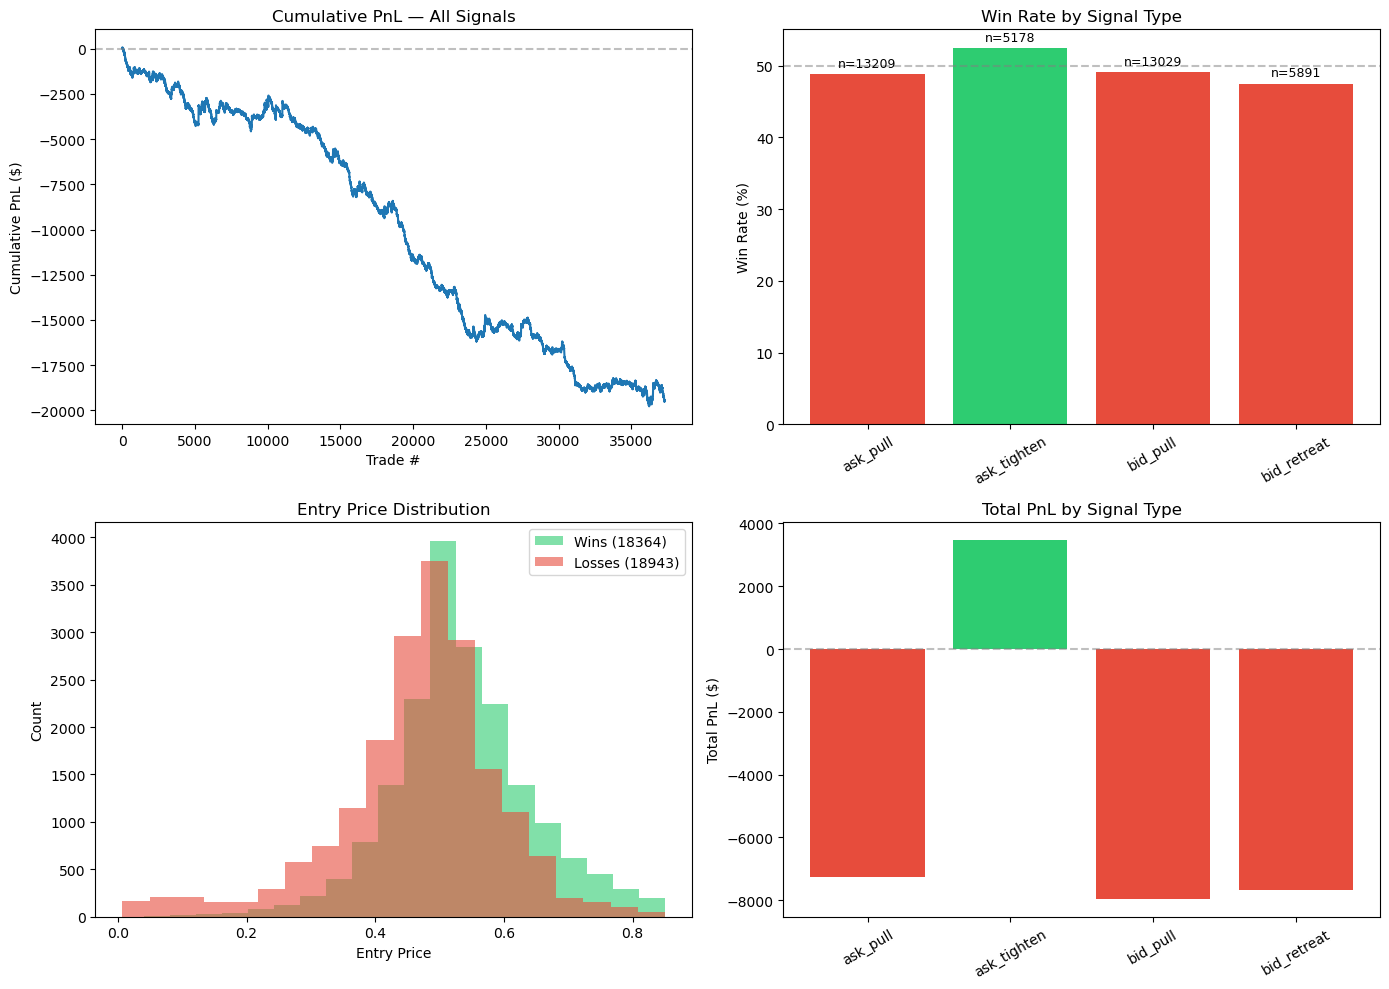

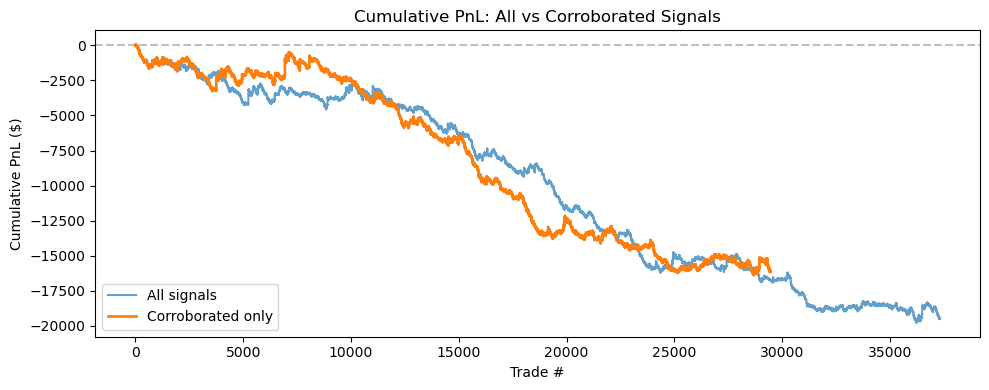

In [32]:
if len(trades) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Cumulative PnL
    ax = axes[0, 0]
    cum_pnl = trades.pnl.cumsum()
    ax.plot(range(len(cum_pnl)), cum_pnl, linewidth=1.5)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Trade #")
    ax.set_ylabel("Cumulative PnL ($)")
    ax.set_title("Cumulative PnL — All Signals")
    
    # 2. Win rate by signal type
    ax = axes[0, 1]
    wr_by_type = trades.groupby("signal_type").correct.mean() * 100
    count_by_type = trades.groupby("signal_type").size()
    bars = ax.bar(wr_by_type.index, wr_by_type.values, color=["#2ecc71" if w > 50 else "#e74c3c" for w in wr_by_type])
    ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel("Win Rate (%)")
    ax.set_title("Win Rate by Signal Type")
    for bar, cnt in zip(bars, count_by_type.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"n={cnt}", ha="center", fontsize=9)
    ax.tick_params(axis="x", rotation=30)
    
    # 3. Entry price distribution (wins vs losses)
    ax = axes[1, 0]
    wins = trades[trades.correct]
    losses = trades[~trades.correct]
    ax.hist(wins.entry_price, bins=20, alpha=0.6, label=f"Wins ({len(wins)})", color="#2ecc71")
    ax.hist(losses.entry_price, bins=20, alpha=0.6, label=f"Losses ({len(losses)})", color="#e74c3c")
    ax.set_xlabel("Entry Price")
    ax.set_ylabel("Count")
    ax.set_title("Entry Price Distribution")
    ax.legend()
    
    # 4. PnL by signal type
    ax = axes[1, 1]
    pnl_by_type = trades.groupby("signal_type").pnl.sum()
    colors = ["#2ecc71" if p > 0 else "#e74c3c" for p in pnl_by_type]
    ax.bar(pnl_by_type.index, pnl_by_type.values, color=colors)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
    ax.set_ylabel("Total PnL ($)")
    ax.set_title("Total PnL by Signal Type")
    ax.tick_params(axis="x", rotation=30)
    
    plt.tight_layout()
    plt.show()
    
    # Corroborated PnL curve if available
    if len(trades_corr) > 0:
        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
        ax.plot(range(len(trades)), trades.pnl.cumsum(), label="All signals", alpha=0.7)
        ax.plot(range(len(trades_corr)), trades_corr.pnl.cumsum(), label="Corroborated only", linewidth=2)
        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
        ax.set_xlabel("Trade #")
        ax.set_ylabel("Cumulative PnL ($)")
        ax.set_title("Cumulative PnL: All vs Corroborated Signals")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No trades to visualize. Check signal extraction and 5m market matching.")

## Step 9: Signal timing analysis

How much time is there between the whale signal and the 5m market resolution? Do signals cluster at certain points in the 4h market lifecycle?

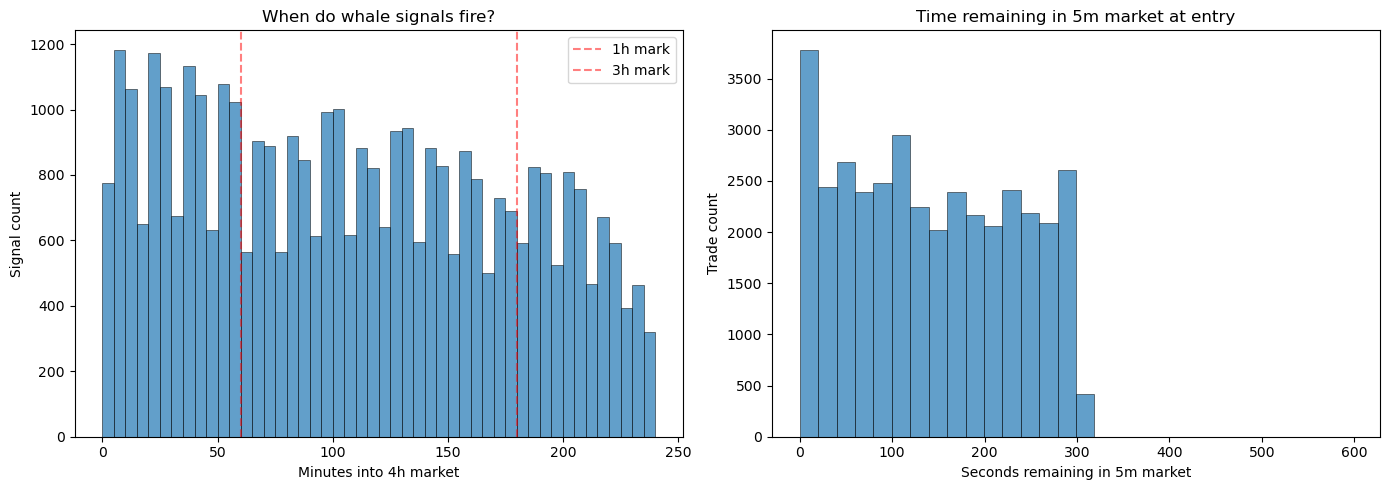


Win rate by hour into 4h market:
  Hour 0: 11508 trades, WR=49.3%, PnL=$-5114.46
  Hour 1: 9625 trades, WR=49.2%, PnL=$-6117.61
  Hour 2: 8962 trades, WR=49.2%, PnL=$-5187.99
  Hour 3: 7212 trades, WR=49.1%, PnL=$-3021.89


In [33]:
if len(trades) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Time into 4h market when signal fires
    trades["time_into_4h_min"] = (trades.ts_ms / 1000 - trades.market_4h_epoch) / 60
    
    ax = axes[0]
    ax.hist(trades.time_into_4h_min, bins=48, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Minutes into 4h market")
    ax.set_ylabel("Signal count")
    ax.set_title("When do whale signals fire?")
    ax.axvline(x=60, color="red", linestyle="--", alpha=0.5, label="1h mark")
    ax.axvline(x=180, color="red", linestyle="--", alpha=0.5, label="3h mark")
    ax.legend()
    
    # Time remaining in 5m market when signal fires
    trades["time_remaining_5m_s"] = (trades.market_5m_epoch + 300) - trades.ts_ms / 1000
    
    ax = axes[1]
    ax.hist(trades.time_remaining_5m_s, bins=30, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Seconds remaining in 5m market")
    ax.set_ylabel("Trade count")
    ax.set_title("Time remaining in 5m market at entry")
    
    plt.tight_layout()
    plt.show()
    
    # Win rate by time into 4h market
    trades["hour_bucket"] = (trades.time_into_4h_min // 60).astype(int)
    print("\nWin rate by hour into 4h market:")
    for h, grp in trades.groupby("hour_bucket"):
        print(f"  Hour {h}: {len(grp)} trades, WR={grp.correct.mean()*100:.1f}%, PnL=${grp.pnl.sum():.2f}")
else:
    print("No trades to analyze")

## Step 10: False positive analysis & signal quality

Examine losing trades to understand signal failure modes. Are there specific conditions where the whale signal is unreliable?

In [34]:
if len(trades) > 0:
    losses = trades[~trades.correct]
    wins = trades[trades.correct]
    
    print(f"=== False Positive Analysis ===")
    print(f"Total losses: {len(losses)} / {len(trades)} ({len(losses)/len(trades)*100:.1f}%)")
    print(f"Total loss amount: ${losses.pnl.sum():.2f}")
    print(f"\nLosing trades by signal type:")
    for st, grp in losses.groupby("signal_type"):
        total_of_type = len(trades[trades.signal_type == st])
        print(f"  {st}: {len(grp)}/{total_of_type} losses ({len(grp)/total_of_type*100:.1f}%)")
    
    print(f"\nLosing trades by entry price bucket:")
    for bucket, grp in losses.groupby(pd.cut(losses.entry_price, bins=[0, 0.3, 0.5, 0.6, 0.7, 0.85])):
        total_in_bucket = len(trades[pd.cut(trades.entry_price, bins=[0, 0.3, 0.5, 0.6, 0.7, 0.85]) == bucket])
        if total_in_bucket > 0:
            print(f"  {bucket}: {len(grp)}/{total_in_bucket} losses ({len(grp)/total_in_bucket*100:.1f}%)")
    
    print(f"\nSample losing trades:")
    for _, row in losses.head(10).iterrows():
        print(f"  {row.detail} → predicted {row.direction}, entry={row.entry_price:.2f}, PnL=${row.pnl:.2f}")
else:
    print("No trades to analyze")

=== False Positive Analysis ===
Total losses: 18943 / 37307 (50.8%)
Total loss amount: $-378860.00

Losing trades by signal type:
  ask_pull: 6756/13209 losses (51.1%)
  ask_tighten: 2462/5178 losses (47.5%)
  bid_pull: 6633/13029 losses (50.9%)
  bid_retreat: 3092/5891 losses (52.5%)

Losing trades by entry price bucket:
  (0.0, 0.3]: 1763/2152 losses (81.9%)
  (0.3, 0.5]: 9284/16332 losses (56.8%)
  (0.5, 0.6]: 6084/13080 losses (46.5%)
  (0.6, 0.7]: 1415/4165 losses (34.0%)
  (0.7, 0.85]: 397/1578 losses (25.2%)

Sample losing trades:
  Up bid 0.53 (2600) GONE (44 snaps) → predicted down, entry=0.18, PnL=$-20.00
  Up bid 0.57 (2600) GONE (11 snaps) → predicted down, entry=0.18, PnL=$-20.00
  Up bid 0.55 (2500) GONE (30 snaps) → predicted down, entry=0.18, PnL=$-20.00
  Down bid 0.34 (2500) GONE (11 snaps) → predicted up, entry=0.53, PnL=$-20.00
  Up ask 0.65 (2535) GONE (6 snaps) → predicted up, entry=0.53, PnL=$-20.00
  Up ask 0.66 (2500) GONE (19 snaps) → predicted up, entry=0.53,

## Notes & Caveats

**Token identity**: Using `telonex_book_snapshots` which has definitive `token_label` ("Up"/"Down") columns — no heuristic needed for token identification.

**Potential improvements**:
1. Test with tighter WHALE_MOVE_TICKS for retreat/tighten signals
2. Add a "signal strength" filter — only trade when whale order size is above median
3. Analyze latency sensitivity: how does win rate degrade as we delay entry by 1s, 2s, 5s?
4. Consider using whale signals as a filter for the XGBoost model rather than standalone
5. Test signal persistence: does the whale stay out, or do they re-enter quickly (false alarm)?

**Execution considerations**:
- Real entry would use limit orders, not market orders — actual entry price may be better
- Signal detection latency: need to process 4h orderbook updates in real-time
- Multiple signals in quick succession: cooldown prevents overtrading but may miss valid follow-ups
- 5m telonex data only has 5 book levels (vs 10 in raw book_snapshots) — sufficient for entry pricing